In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns 


In [2]:
df = pd.read_csv("smartcart_customers.csv")

In [3]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


In [4]:
df.info

<bound method DataFrame.info of          ID  Year_Birth   Education Marital_Status   Income  Kidhome  \
0      5524        1957  Graduation         Single  58138.0        0   
1      2174        1954  Graduation         Single  46344.0        1   
2      4141        1965  Graduation       Together  71613.0        0   
3      6182        1984  Graduation       Together  26646.0        1   
4      5324        1981         PhD        Married  58293.0        1   
...     ...         ...         ...            ...      ...      ...   
2235  10870        1967  Graduation        Married  61223.0        0   
2236   4001        1946         PhD       Together  64014.0        2   
2237   7270        1981  Graduation       Divorced  56981.0        0   
2238   8235        1956      Master       Together  69245.0        0   
2239   9405        1954         PhD        Married  52869.0        1   

      Teenhome Dt_Customer  Recency  MntWines  ...  MntFishProducts  \
0            0  04-09-2012      

In [6]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

# data preprocessing 


## Handle the missing values

In [7]:
df["Income"] = df["Income"].fillna(df["Income"].median())

In [9]:
df.head()
df.isnull().sum()

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
Complain               0
Response               0
dtype: int64

# feature engineering

In [10]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response'],
      dtype='object')

In [11]:
#age 
df["age"] = 2026-df["Year_Birth"]

In [12]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,age
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,88,88,3,8,10,4,7,0,1,69
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,1,6,2,1,1,2,5,0,0,72
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,21,42,1,8,2,10,4,0,0,61
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,3,5,2,2,0,4,6,0,0,42
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,27,15,5,5,3,6,5,0,0,45


In [16]:
# Customer Joining date 
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"],dayfirst = True)
refrence_date = df["Dt_Customer"].max()
df["Customer_Tenure_Days"] = (refrence_date -df["Dt_Customer"]).dt.days

In [17]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,age,Customer_Tenure_Days
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,88,3,8,10,4,7,0,1,69,663
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,6,2,1,1,2,5,0,0,72,113
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,42,1,8,2,10,4,0,0,61,312
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,5,2,2,0,4,6,0,0,42,139
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,15,5,5,3,6,5,0,0,45,161


In [20]:
# Spanding 
df["Total_Spending"] = df["MntWines"]+df["MntFruits"]+df["MntMeatProducts"]+df["MntFishProducts"]+df["MntSweetProducts"]+df["MntGoldProds"]


In [21]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,age,Customer_Tenure_Days,Total_Spending
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,3,8,10,4,7,0,1,69,663,1617
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,2,1,1,2,5,0,0,72,113,27
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,1,8,2,10,4,0,0,61,312,776
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,2,2,0,4,6,0,0,42,139,53
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,5,3,6,5,0,0,45,161,422


In [23]:
#Children
df["Total_Children"] = df["Kidhome"]+df["Teenhome"]

In [24]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,age,Customer_Tenure_Days,Total_Spending,Total_Children
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,8,10,4,7,0,1,69,663,1617,0
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,1,1,2,5,0,0,72,113,27,2
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,8,2,10,4,0,0,61,312,776,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,2,0,4,6,0,0,42,139,53,1
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,3,6,5,0,0,45,161,422,1


In [26]:
# Education
df["Education"].value_counts()


Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64

In [29]:
# Convert to datetime and calculate tenure (if needed from previous step)
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], dayfirst=True)
refrence_date = df["Dt_Customer"].max()
df["Customer_Tenure_Days"] = (refrence_date - df["Dt_Customer"]).dt.days

# Corrected education mapping using .replace()
df["Education"] = df["Education"].replace({
    "Basic": "Undergraduate",
    "2n Cycle": "Undergraduate",
    "Graduation": "Graduate",
    "Master": "Postgraduate",
    "PhD": "Postgraduate"
})

In [30]:
df["Education"].value_counts()

Education
Graduate         1127
Postgraduate      856
Undergraduate     257
Name: count, dtype: int64

In [32]:
df["Marital_Status"].value_counts()

Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

In [69]:
# Marital stutes
df["Living_With"] = df["Marital_Status"].replace({
    "Basic": "Partner",
    "Together": "Partner",
    "Single": "Alone","Divorced":"Alone",
    "Widow": "Alone",
    "Absurd": "Alone",
    "YOLO":"Alone"
})

In [81]:
df["Living_With"].value_counts()

Living_With
Married    864
Alone      796
Partner    580
Name: count, dtype: int64

In [83]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,age,Customer_Tenure_Days,Total_Spending,Total_Children,Living_With
0,5524,1957,Graduate,Alone,58138.0,0,0,2012-09-04,58,635,...,10,4,7,0,1,69,663,1617,0,Alone
1,2174,1954,Graduate,Alone,46344.0,1,1,2014-03-08,38,11,...,1,2,5,0,0,72,113,27,2,Alone
2,4141,1965,Graduate,Partner,71613.0,0,0,2013-08-21,26,426,...,2,10,4,0,0,61,312,776,0,Partner
3,6182,1984,Graduate,Partner,26646.0,1,0,2014-02-10,26,11,...,0,4,6,0,0,42,139,53,1,Partner
4,5324,1981,Postgraduate,Married,58293.0,1,0,2014-01-19,94,173,...,3,6,5,0,0,45,161,422,1,Married


In [84]:
# Fixed column names with correct spellings
cols = ["ID", "Year_Birth", "Marital_Status", "Kidhome", "Teenhome", "Dt_Customer"]
Spending_cols = ["MntWines", "MntMeatProducts", "MntFishProducts", "MntSweetProducts", "MntGoldProds"]

cols_to_drop = cols + Spending_cols
df_cleaned = df.drop(columns=cols_to_drop)

In [85]:
df_cleaned.shape

(2240, 16)

In [86]:
df.shape

(2240, 27)

In [87]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'age', 'Customer_Tenure_Days', 'Total_Spending',
       'Total_Children', 'Living_With'],
      dtype='object')

In [88]:
df_cleaned.head()

,Education,Income,Recency,MntFruits,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,age,Customer_Tenure_Days,Total_Spending,Total_Children,Living_With
0,Graduate,58138.0,58,88,3,8,10,4,7,0,1,69,663,1617,0,Alone
1,Graduate,46344.0,38,1,2,1,1,2,5,0,0,72,113,27,2,Alone
2,Graduate,71613.0,26,49,1,8,2,10,4,0,0,61,312,776,0,Partner
3,Graduate,26646.0,26,4,2,2,0,4,6,0,0,42,139,53,1,Partner
4,Postgraduate,58293.0,94,43,5,5,3,6,5,0,0,45,161,422,1,Married


# Outlier

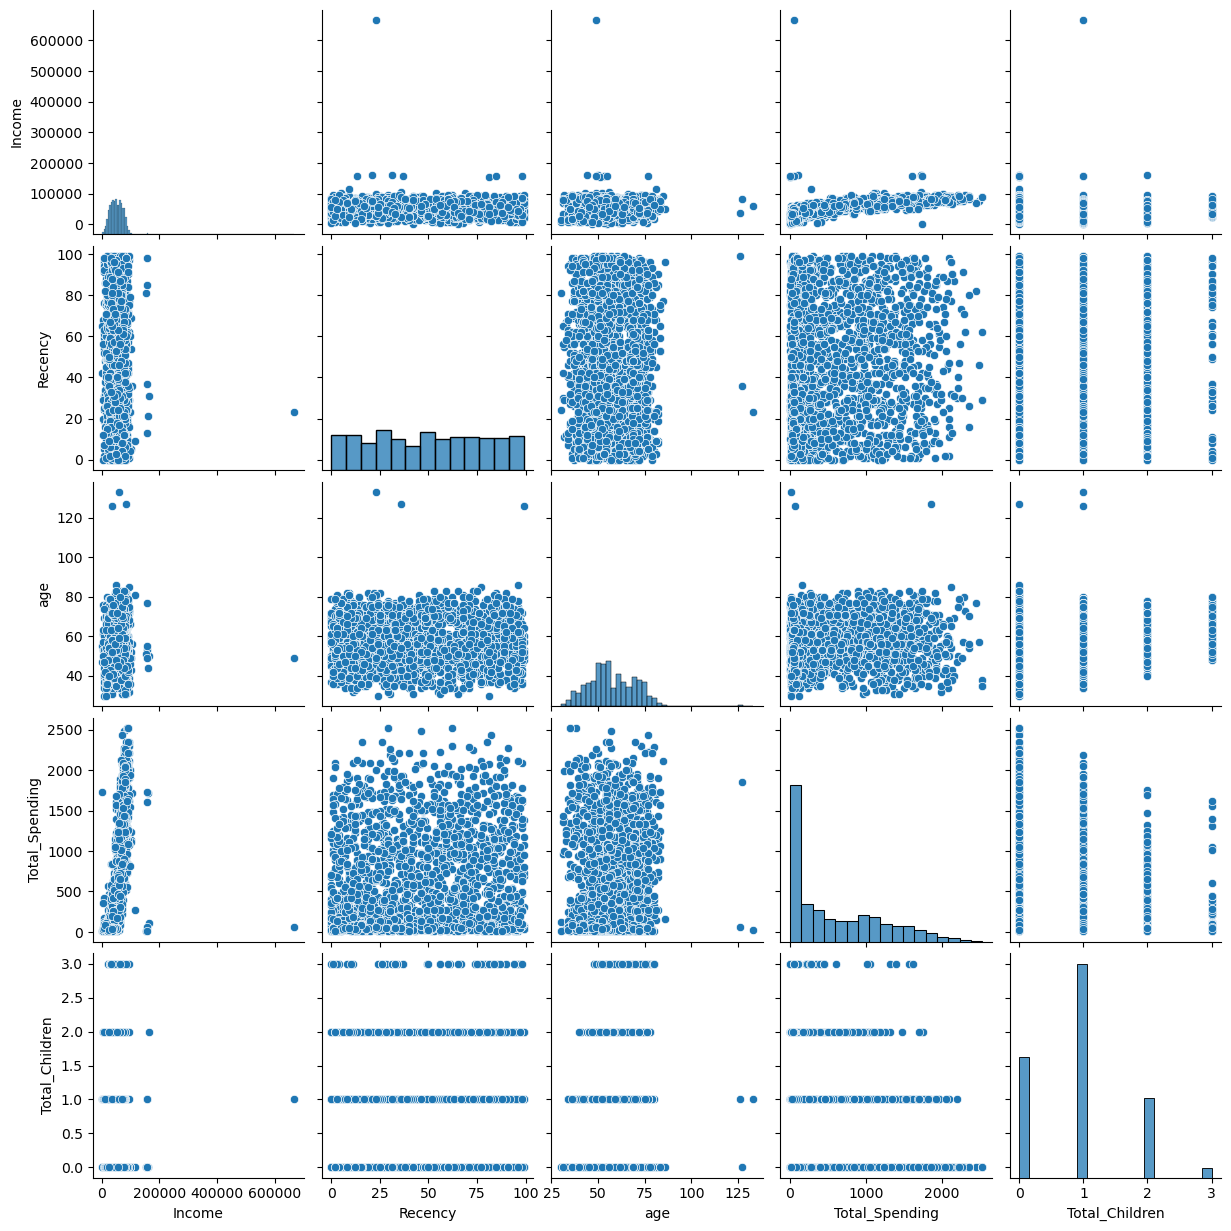

In [89]:
cols = ["Income","Recency","age","Total_Spending","Total_Children"]

#releative plots of some feature - pair plot 
sns.pairplot(df_cleaned[cols])

In [90]:
# Remove Outlier 
print("data size with Outlier:",len(df_cleaned))
df_cleaned = df_cleaned[ (df_cleaned["age"]<90) ]
df_cleaned = df_cleaned[ (df_cleaned["Income"]<600_000) ]

print("data size with Outlier:",len(df_cleaned))


data size with Outlier: 2240
data size with Outlier: 2236


# Heat map 

In [91]:
corr = df_cleaned.corr(numeric_only =True)


<Axes: >

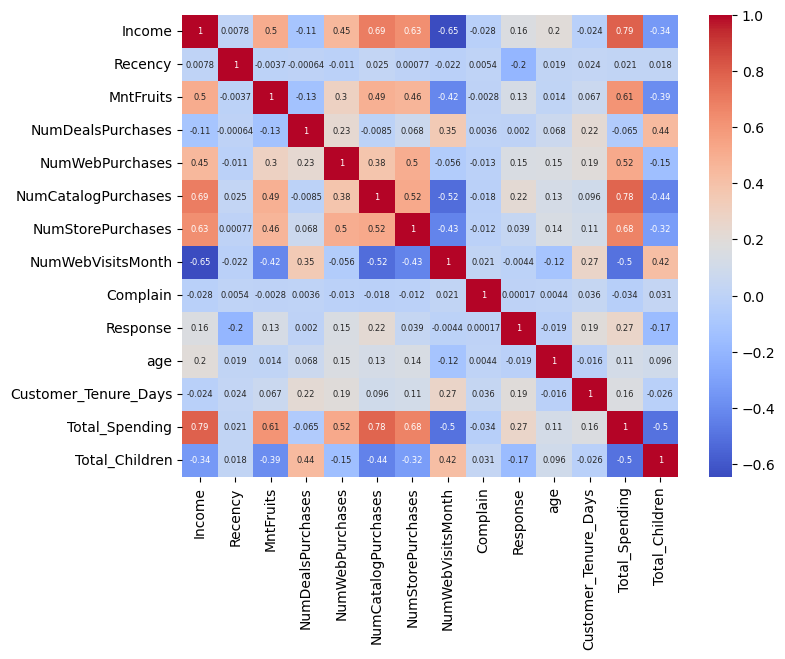

In [92]:
plt.figure(figsize=(8,6))
sns.heatmap(
    corr,
    annot = True,
    annot_kws = {"size": 6},
    cmap ="coolwarm"
)

In [93]:
df_cleaned.shape

(2236, 16)

In [94]:
df_cleaned.head()

,Education,Income,Recency,MntFruits,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,age,Customer_Tenure_Days,Total_Spending,Total_Children,Living_With
0,Graduate,58138.0,58,88,3,8,10,4,7,0,1,69,663,1617,0,Alone
1,Graduate,46344.0,38,1,2,1,1,2,5,0,0,72,113,27,2,Alone
2,Graduate,71613.0,26,49,1,8,2,10,4,0,0,61,312,776,0,Partner
3,Graduate,26646.0,26,4,2,2,0,4,6,0,0,42,139,53,1,Partner
4,Postgraduate,58293.0,94,43,5,5,3,6,5,0,0,45,161,422,1,Married


# Encoding

In [95]:
from sklearn.preprocessing import OneHotEncoder

In [96]:
ohe = OneHotEncoder()

# Ensure both columns exist in df before passing them
cat_cols = ["Education", "Living_With"] 

enc_cols = ohe.fit_transform(df[cat_cols])

In [99]:
# 1. Verify what values are inside Living_With
print(df["Living_With"].value_counts(dropna=False))

# 2. Re-run OneHotEncoder ensuring both columns have valid data
cat_cols = ["Education", "Living_With"]

# Drop any rows where these categorical columns are missing
df_encoded_subset = df[cat_cols].dropna()

ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
enc_cols = ohe.fit_transform(df_encoded_subset)

# 3. Create enc_df safely using the matching subset index
enc_df = pd.DataFrame(
    enc_cols,
    columns=ohe.get_feature_names_out(cat_cols),
    index=df_encoded_subset.index
)

print(enc_df.head())

Living_With
Married    864
Alone      796
Partner    580
Name: count, dtype: int64
   Education_Graduate  Education_Postgraduate  Education_Undergraduate  \
0                 1.0                     0.0                      0.0   
1                 1.0                     0.0                      0.0   
2                 1.0                     0.0                      0.0   
3                 1.0                     0.0                      0.0   
4                 0.0                     1.0                      0.0   

   Living_With_Alone  Living_With_Married  Living_With_Partner  
0                1.0                  0.0                  0.0  
1                1.0                  0.0                  0.0  
2                0.0                  0.0                  1.0  
3                0.0                  0.0                  1.0  
4                0.0                  1.0                  0.0  


In [100]:
enc_df.head()

,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_Married,Living_With_Partner
0,1.0,0.0,0.0,1.0,0.0,0.0
1,1.0,0.0,0.0,1.0,0.0,0.0
2,1.0,0.0,0.0,0.0,0.0,1.0
3,1.0,0.0,0.0,0.0,0.0,1.0
4,0.0,1.0,0.0,0.0,1.0,0.0


In [102]:
df_encoded=pd.concat([df_cleaned.drop(columns = cat_cols),enc_df],axis =1)


In [104]:
df_encoded.shape

(2240, 20)

In [105]:
df_encoded.head()

,Income,Recency,MntFruits,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,age,Customer_Tenure_Days,Total_Spending,Total_Children,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_Married,Living_With_Partner
0,58138.0,58.0,88.0,3.0,8.0,10.0,4.0,7.0,0.0,1.0,69.0,663.0,1617.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
1,46344.0,38.0,1.0,2.0,1.0,1.0,2.0,5.0,0.0,0.0,72.0,113.0,27.0,2.0,1.0,0.0,0.0,1.0,0.0,0.0
2,71613.0,26.0,49.0,1.0,8.0,2.0,10.0,4.0,0.0,0.0,61.0,312.0,776.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
3,26646.0,26.0,4.0,2.0,2.0,0.0,4.0,6.0,0.0,0.0,42.0,139.0,53.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0
4,58293.0,94.0,43.0,5.0,5.0,3.0,6.0,5.0,0.0,0.0,45.0,161.0,422.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0


# Scaling

In [106]:
from sklearn.preprocessing import StandardScaler


In [109]:
X = df_encoded

In [110]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [111]:
X_scaled

array([[ 0.28894655,  0.30685572,  1.55417019, ...,  1.34687429,
        -0.79240582, -0.59109863],
       [-0.262003  , -0.38397129, -0.63643109, ...,  1.34687429,
        -0.79240582, -0.59109863],
       [ 0.91842301, -0.7984675 ,  0.57217651, ..., -0.74245979,
        -0.79240582,  1.69176504],
       ...,
       [        nan,         nan,         nan, ...,  1.34687429,
        -0.79240582, -0.59109863],
       [        nan,         nan,         nan, ..., -0.74245979,
        -0.79240582,  1.69176504],
       [        nan,         nan,         nan, ..., -0.74245979,
        -0.79240582,  1.69176504]])

In [112]:
# visulizing data 
X_scaled.shape

(2240, 20)

In [113]:
# 2D

from sklearn.decomposition import PCA


In [122]:
from sklearn.impute import SimpleImputer

# Fill missing values with the mean of each column
imputer = SimpleImputer(strategy='mean')
X_imputed = imputer.fit_transform(X)

# Then scale and run PCA
X_scaled = scaler.fit_transform(X_imputed)
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

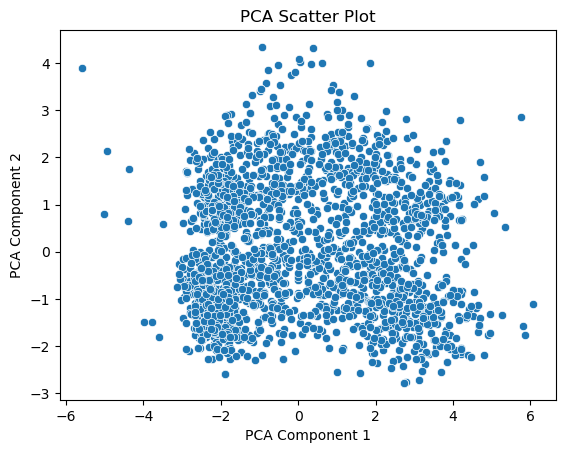

In [123]:
import seaborn as sns
import matplotlib.pyplot as plt

# Using seaborn's scatterplot
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1])
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("PCA Scatter Plot")
plt.show()

In [124]:
pca.explained_variance_ratio_

array([0.22937683, 0.09533897, 0.08932497])

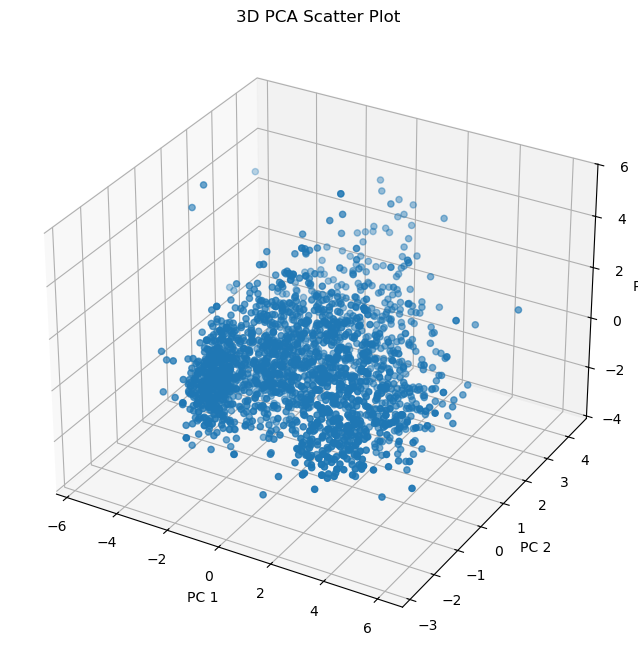

In [134]:
import matplotlib.pyplot as plt

# Make sure your PCA is set to 3 components for a 3D plot
# pca = PCA(n_components=3)
# X_pca = pca.fit_transform(X_scaled)

fig = plt.figure(figsize=(10,8))

# Fixed spelling: 'projection' instead of 'projecton'
ax = fig.add_subplot(111, projection="3d")

# Fixed method: ax.scatter instead of ax.scatterplot
ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2])

ax.set_xlabel("PC 1")
ax.set_ylabel("PC 2")
ax.set_zlabel("PC 3")
plt.title("3D PCA Scatter Plot")
plt.show()

# Analyze k method

## Elbow method

In [136]:
from sklearn.cluster import KMeans
from kneed import KneeLocator  # Fixed capitalization: 'kneed'

wcss = []
for k in range(1, 11):
    # Use consistent lowercase 'kmeans'
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(X_pca)
    wcss.append(kmeans.inertia_)

C:\ProgramData\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\ProgramData\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\ProgramData\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\ProgramData\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^

In [138]:
knee = KneeLocator(range(1,11),wcss,curve = "convex", direction = "decreasing")
optimal_k = knee.elbow

In [140]:
print("best k =",optimal_k)

best k = 4


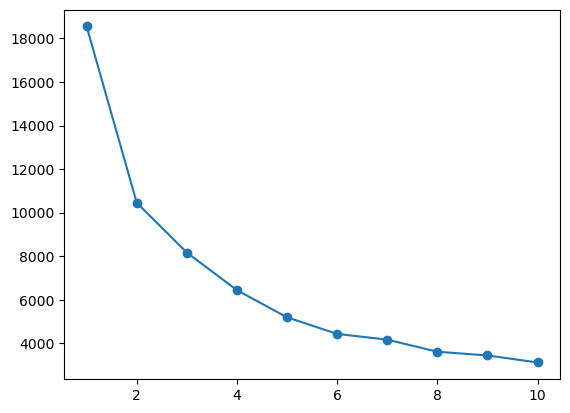

In [142]:
#plot 
plt.plot(range(1,11),wcss,marker='o')

## Silhouette Score

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

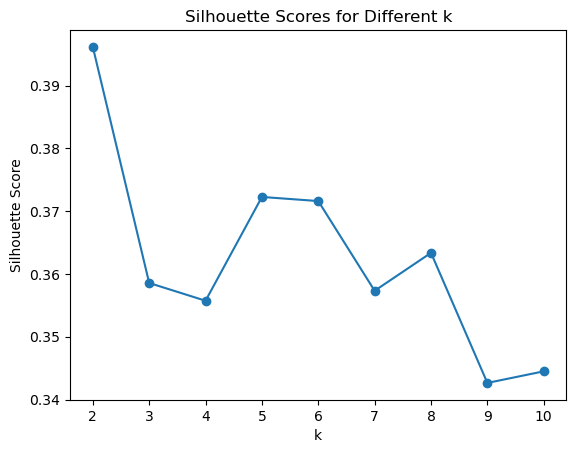

In [147]:
from sklearn.metrics import silhouette_score

scores = []
for k in range(2, 11):
    # Fixed variable name spelling to 'kmeans'
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    labels = kmeans.fit_predict(X_pca)
    
    # Fixed spelling of 'silhouette_score'
    score = silhouette_score(X_pca, labels)
    scores.append(score)

# Plot
plt.plot(range(2, 11), scores, marker='o')
plt.xlabel("k")
plt.ylabel("Silhouette Score")  # Fixed spelling
plt.title("Silhouette Scores for Different k")
plt.show()

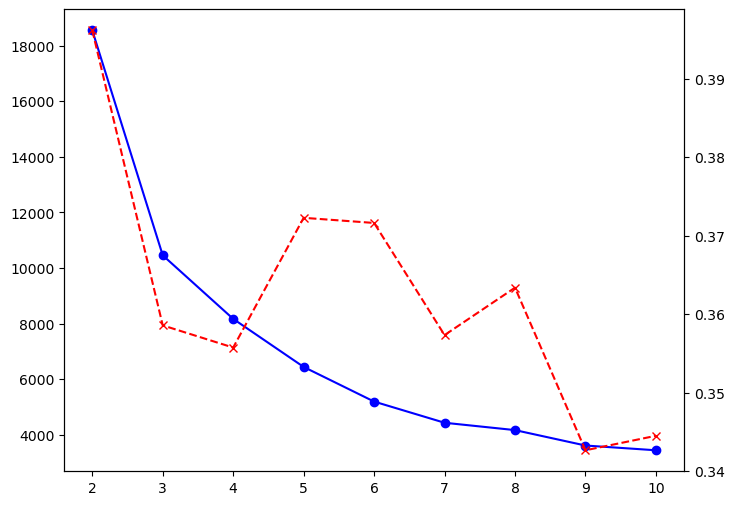

In [152]:
#combine plot 
k_range = range(2,11)
fig , ax1 = plt.subplots(figsize = (8,6))
ax1.plot(k_range,wcss[:len(k_range)],marker = 'o',color = "blue")
ax2 = ax1.twinx()
ax2.plot(k_range,scores[:len(k_range)],marker="x",color = "red",linestyle = "--")

# Clutering

In [154]:
#k_means 
Kmeans = KMeans(n_clusters =4,random_state=42)
labels_Kmeans= Kmeans.fit_predict(X_pca)

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(


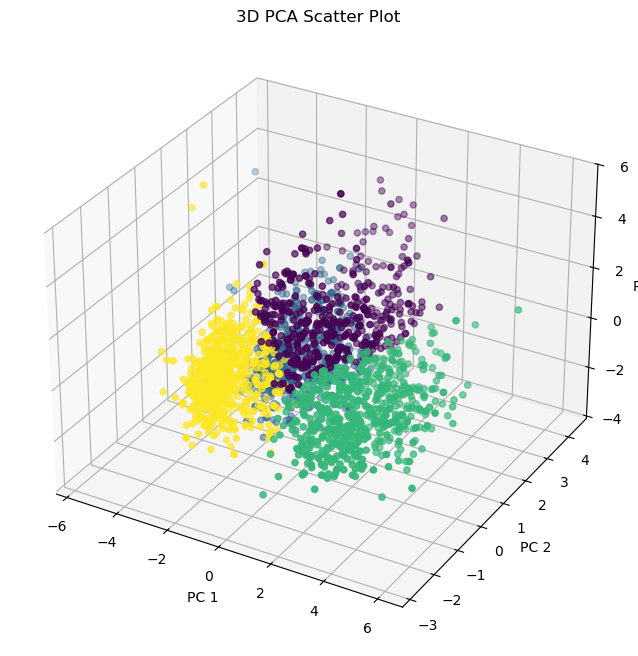

In [155]:
import matplotlib.pyplot as plt

# Make sure your PCA is set to 3 components for a 3D plot
# pca = PCA(n_components=3)
# X_pca = pca.fit_transform(X_scaled)

fig = plt.figure(figsize=(10,8))

# Fixed spelling: 'projection' instead of 'projecton'
ax = fig.add_subplot(111, projection="3d")

# Fixed method: ax.scatter instead of ax.scatterplot
ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2],c=labels_Kmeans)

ax.set_xlabel("PC 1")
ax.set_ylabel("PC 2")
ax.set_zlabel("PC 3")
plt.title("3D PCA Scatter Plot")
plt.show()

In [156]:
#aglomaritive clustring 
from sklearn.cluster import AgglomerativeClustering

In [157]:
agg_clf = AgglomerativeClustering(n_clusters=4, linkage = "ward")
labels = agg_clf.fit_predict(X_pca)

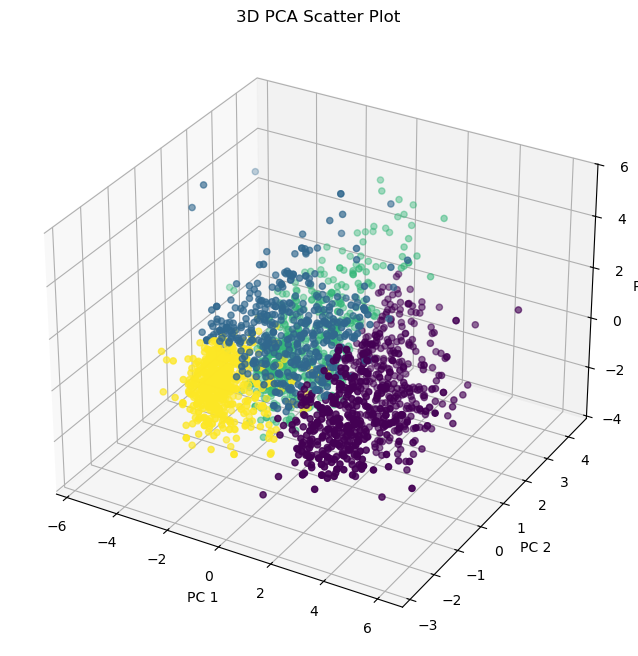

In [158]:
import matplotlib.pyplot as plt

# Make sure your PCA is set to 3 components for a 3D plot
# pca = PCA(n_components=3)
# X_pca = pca.fit_transform(X_scaled)

fig = plt.figure(figsize=(10,8))

# Fixed spelling: 'projection' instead of 'projecton'
ax = fig.add_subplot(111, projection="3d")

# Fixed method: ax.scatter instead of ax.scatterplot
ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2],c=labels)

ax.set_xlabel("PC 1")
ax.set_ylabel("PC 2")
ax.set_zlabel("PC 3")
plt.title("3D PCA Scatter Plot")
plt.show()

# Characterization of clusters

In [170]:
# Option A: Assign the labels to your original full dataframe 'df' 
# (Make sure X_pca was generated from the full df, or use df.loc for the cleaned subset)
X["labels"] = labels_agg

In [171]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumStorePurchases,NumWebVisitsMonth,Complain,Response,age,Customer_Tenure_Days,Total_Spending,Total_Children,Living_With,labels
0,5524,1957,Graduate,Alone,58138.0,0,0,2012-09-04,58,635,...,4,7,0,1,69,663,1617,0,Alone,1
1,2174,1954,Graduate,Alone,46344.0,1,1,2014-03-08,38,11,...,2,5,0,0,72,113,27,2,Alone,0
2,4141,1965,Graduate,Partner,71613.0,0,0,2013-08-21,26,426,...,10,4,0,0,61,312,776,0,Partner,1
3,6182,1984,Graduate,Partner,26646.0,1,0,2014-02-10,26,11,...,4,6,0,0,42,139,53,1,Partner,0
4,5324,1981,Postgraduate,Married,58293.0,1,0,2014-01-19,94,173,...,6,5,0,0,45,161,422,1,Married,2


C:\Users\arjun\AppData\Local\Temp\ipykernel_10160\3669222643.py:3: UserWarning: The palette list has more values (5) than needed (3), which may not be intended.
  sns.countplot(x=X["labels"],palette=pal, hue= X["labels"])


<Axes: xlabel='labels', ylabel='count'>

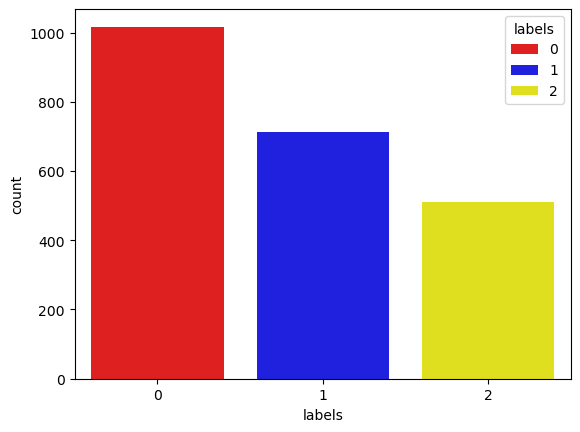

In [172]:
pal = ["red","blue","yellow","green","black"]

sns.countplot(x=X["labels"],palette=pal, hue= X["labels"])

C:\Users\arjun\AppData\Local\Temp\ipykernel_10160\1044342662.py:2: UserWarning: The palette list has more values (5) than needed (3), which may not be intended.
  sns.scatterplot(x=X["Total_Spending"],y=X["Income"],palette = pal,hue = X["labels"])


<Axes: xlabel='Total_Spending', ylabel='Income'>

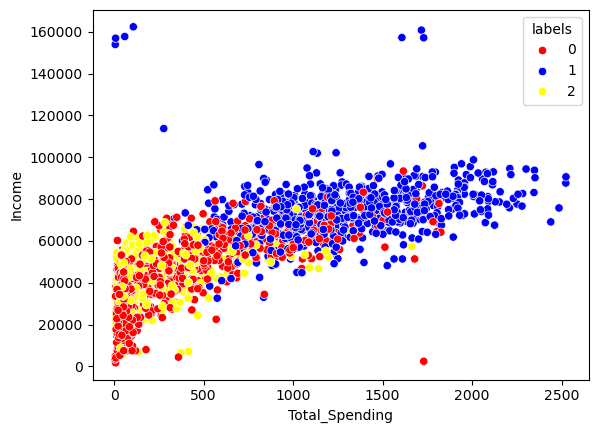

In [174]:
# Income & Spending patterns
sns.scatterplot(x=X["Total_Spending"],y=X["Income"],palette = pal,hue = X["labels"])

In [178]:
# cluster summary 
labels_summary = X.groupby("labels").mean()
print(labels_summary)

              Income    Recency  MntFruits  NumDealsPurchases  \
labels                                                          
0       40887.500000  49.738659  13.835306           2.678501   
1       74380.327949  49.360955  59.318820           1.490169   
2       42641.816667  47.537255   4.880392           2.792157   

        NumWebPurchases  NumCatalogPurchases  NumStorePurchases  \
labels                                                            
0              3.541420             1.364892           4.594675   
1              5.387640             5.608146           8.588483   
2              3.358824             1.133333           4.284314   

        NumWebVisitsMonth  Complain  Response        age  \
labels                                                     
0                6.335306  0.015779  0.085799  55.022682   
1                3.136236  0.005618  0.254213  58.839888   
2                6.345098  0.000000  0.129412  58.809804   

        Customer_Tenure_Days  Total_S